# Crawling Data kualitas udara di wilayah Dukun, Gresik

# Business Understanding

## Latar Belakang dan Tujuan Proyek

Tujuan utama dari proyek sains data ini adalah:

> **"Menganalisis kualitas udara di wilayah Gresik berdasarkan perubahan konsentrasi polutan NO₂ secara temporal selama periode 1 tahun terakhir menggunakan data satelit penginderaan jauh Sentinel-5P."**

Tujuan di atas dirumuskan secara spesifik agar mencakup komponen penting dalam proyek sains data:
- **Data:** Konsentrasi polutan (NO₂)
- **Periode waktu:** 1 tahun terakhir (31 Agustus 2025 hingga 31 Agustus 2026)
- **Wilayah:** Kecamatan Dukun, Gresik (berdasarkan batas koordinat wilayah)
- **Analisis:** Analisis temporal (*Time Series*)
- **Output:** Visualisasi data dan penarikan kesimpulan terkait tren kualitas udara

# Data Understanding

Berdasarkan ketersediaan instrumen (*band*) pada satelit **Sentinel-5P** yang digunakan dalam proyek ini, kita akan berfokus pada NO₂

| Parameter | Nama Polutan | Mengapa Penting? | Sumber Umum |
| :---: | :--- | :--- | :--- |
| **NO₂** | *Nitrogen Dioxide* | Berkaitan erat dengan pembakaran kendaraan bermotor dan aktivitas kawasan industri. | Asap kendaraan bermotor, pabrik industri, dan pembangkit listrik. |

## Eksplorasi data - Analisis kualitas udara wilayah Gresik

### Sumber Data (Data Source)
Data kualitas udara yang digunakan bersumber dari pantauan satelit penginderaan jauh **Sentinel-5P (S5P) Precursor**. Satelit ini dilengkapi instrumen TROPOMI yang sangat sensitif dalam mendeteksi komposisi gas di atmosfer. Pengambilan data dilakukan secara komputasional (*crawling*) menggunakan platform Copernicus Data Space melalui pustaka/API `openeo`.

### Spesifikasi Pengambilan Data (Data Scope)
* **Cakupan Spasial (*Spatial Extent*):** Pengambilan data difokuskan secara eksklusif pada *Area of Interest* (AOI) Kecamatan Dukun, Gresik. Ekstraksi menggunakan *Bounding Box* koordinat yang mencakup wilayah daratan dan pesisir sekitar Gresik.
* **Cakupan Temporal (*Temporal Extent*):** Data historis ditarik mulai dari **31 Agustus 2025 hingga 31 Agustus 2026** guna menangkap variasi harian, bulanan, maupun musiman selama lebih dari 1 tahun terakhir.
* **Agregasi (*Aggregation*):**
  * *Temporal*: Data harian diagregasi dengan menghitung nilai rata-rata (*daily mean*) untuk menghindari duplikasi observasi pada hari yang sama.
  * *Spasial*: Seluruh nilai piksel satelit yang jatuh di dalam batas koordinat Dukun, Gresik dirata-ratakan (*spatial mean*), menghasilkan satu nilai representatif untuk keseluruhan area pada hari tersebut.

### Deskripsi Variabel (Features Description)
Terdapat variabel polutan utama (NO₂) dan satu variabel waktu yang diekstrak:
1. **NO₂ (Nitrogen Dioksida):** Indikator pembakaran bahan bakar, relevan untuk memantau emisi lalu lintas dan kawasan industri di Gresik.
2. **Date (Tanggal):** Indeks waktu perekaman satelit dalam format YYYY-MM-DD.

### Pertimbangan Kualitas Data
Dalam memproses data satelit ini, beberapa hal perlu diperhatikan:
* **Missing Values (Kekosongan Data):** Tutupan awan yang tebal dapat menghalangi sensor satelit merekam permukaan bumi secara sempurna, menghasilkan baris data kosong (NaN).
* **Outliers (Pencilan):** Nilai polutan yang melompat drastis pada hari tertentu harus dicek apakah itu anomali sensor, atau benar-benar ada fenomena nyata (misal: kebakaran atau lonjakan aktivitas pabrik).


### Crawling Data

In [1]:
# Install library untuk crawling dan manipulasi data
!pip install openeo netCDF4 pandas numpy

In [2]:
# Koneksi ke Server Copernicus (OpenEO)
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


#### Eksekusi Crawling Data Satelit (NO₂)

In [3]:
# Polygon Wilayah Kecamatan Dukun
dukun_aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.4176093, -6.9520018],
            [112.4965324, -6.9660151],
            [112.5251805, -6.9804942],
            [112.525, -7.0],
            [112.51, -7.02],
            [112.48, -7.025],
            [112.44, -7.015],
            [112.3681227, -6.9870542],
            [112.381574, -6.9581535],
            [112.4176093, -6.9520018]
        ]
    ]
}

# Bounding Box Kecamatan Dukun (Diambil dari nilai min/max koordinat di atas)
bbox_dukun = {
    "west": 112.3681227,    # Bujur terkecil (Paling Barat)
    "south": -7.025,        # Lintang terkecil (Paling Selatan)
    "east": 112.5251805,    # Bujur terbesar (Paling Timur)
    "north": -6.9520018     # Lintang terbesar (Paling Utara)
}

rentang_waktu = ["2025-08-31", "2026-08-31"]

# Fungsi bantuan untuk memudahkan load dan agregasi
def crawl_polutan(band_name):
    cube = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=rentang_waktu,
        spatial_extent=bbox_dukun, # Diubah menggunakan bbox_dukun
        bands=[band_name]
    )
    
    # Agregasi waktu (rata-rata harian)
    daily = cube.aggregate_temporal_period(reducer="mean", period="day")
    
    # Agregasi spasial (rata-rata di dalam poligon GeoJSON Dukun)
    aoi_mean = daily.aggregate_spatial(reducer="mean", geometries=dukun_aoi) # Diubah menggunakan dukun_aoi
    
    return aoi_mean

# Menyiapkan proses (data cube) untuk masing-masing polutan di Dukun
s5p_NO2 = crawl_polutan("NO2")

In [4]:
# Eksekusi job dan simpan ke file NetCDF (.nc)
print("Memulai NO2...")
s5p_NO2.execute_batch(title="NO2_Dukun", outputfile="NO2_Dukun.nc")

print("file selesai!")

Memulai NO2...


0:00:00 Job 'j-2609130803054dd08212f2d0cf54d584': send 'start'


0:00:04 Job 'j-2609130803054dd08212f2d0cf54d584': queued (progress 0%)


0:00:09 Job 'j-2609130803054dd08212f2d0cf54d584': queued (progress 0%)


0:00:16 Job 'j-2609130803054dd08212f2d0cf54d584': queued (progress 0%)


0:00:24 Job 'j-2609130803054dd08212f2d0cf54d584': queued (progress 0%)


#### Transformasi Data Mentah (NetCDF ke CSV)

File keluaran Copernicus berformat `.nc` bersifat multidimensi. Kita perlu mengekstrak array konsentrasi polutan dan waktunya, lalu mengonversinya menjadi DataFrame dua dimensi (`.csv`) agar siap pakai untuk analisis lanjutan.

In [5]:
import netCDF4
import pandas as pd

# Daftar polutan dan nama file .nc yang HANYA ADA NO2
polutan_list = ["NO2"]
file_nc = ["NO2_Dukun.nc"]

dfs_list = []

for polutan, file in zip(polutan_list, file_nc):
    try:
        ds = netCDF4.Dataset(file)
        kadar = ds.variables[polutan][:].squeeze() 
        
        # Ekstrak tanggal
        time_var = ds.variables["t"]
        try:
            dates = netCDF4.num2date(time_var[:], units=time_var.units)
        except Exception:
            dates = time_var[:]
        new_dates = [d.strftime('%Y-%m-%d') for d in dates]
            
        df_temp = pd.DataFrame({
            "date": pd.to_datetime(new_dates),
            polutan: kadar
        })
        
        dfs_list.append(df_temp)
        print(f"Berhasil mengekstrak {polutan} (Jumlah data: {len(df_temp)} hari)")
        
    except Exception as e:
        print(f"Error memproses file {file}: {e}")

# Proses langsung menyimpan (tanpa merge karena cuma 1 file)
if dfs_list:
    df_hasil = dfs_list[0] # Ambil dataframe NO2
    
    df_hasil = df_hasil.sort_values('date').reset_index(drop=True)
    df_hasil['date'] = df_hasil['date'].dt.strftime('%Y-%m-%d')
            
    # Export ke CSV
    nama_file_akhir = "NO2_Dukun_Terkini.csv"
    df_hasil.to_csv(nama_file_akhir, index=False)
    print(f"\nSUKSES: Data berhasil dikonversi ke -> {nama_file_akhir}")
    
    # Tampilkan 5 data awal
    display(df_hasil.head())
else:
    print("Gagal mengekstrak data dari file NetCDF.")

Berhasil mengekstrak NO2 (Jumlah data: 218 hari)

SUKSES: Data berhasil dikonversi ke -> NO2_Dukun_Terkini.csv


,date,NO2
0,2025-08-31,0.000029
1,2025-09-01,0.000040
2,2025-09-03,0.000031
3,2025-09-04,0.000021
4,2025-09-05,0.000042


#### Visualisasi Hasil dengan Grafik Kartesius
Menampilkan grafik kartesius (*line plot*) deret waktu konsentrasi polutan kualitas udara (NO₂, CO, SO₂, O₃) di area Kabupaten Gresik selama rentang waktu lebih dari 1 tahun terakhir.

In [6]:
!pip install matplotlib

#### Visualisasi NO2

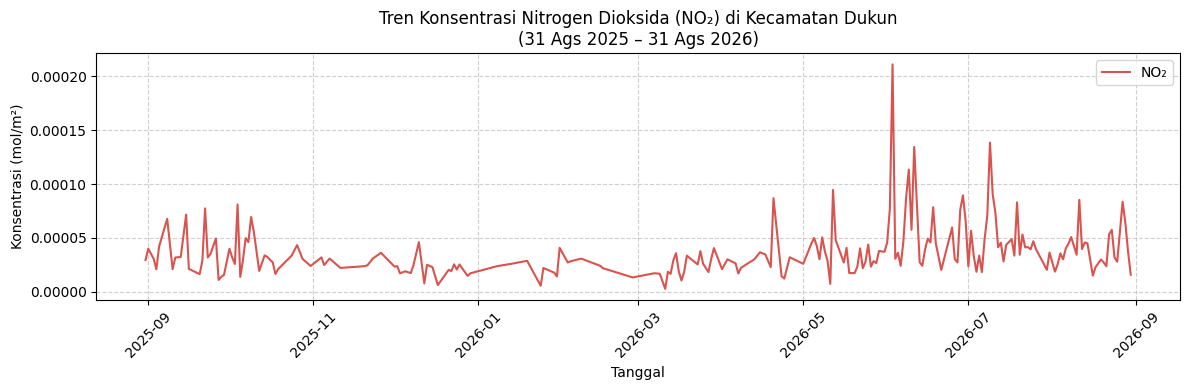

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Sesuaikan nama file dengan output CSV terakhir Anda
df_no2 = pd.read_csv("NO2_Dukun_Terkini.csv")

df_no2 = df_no2.dropna(subset=['NO2']).copy()
df_no2['date'] = pd.to_datetime(df_no2['date'])

fig, ax = plt.subplots(figsize=(12, 4), dpi=100)
ax.plot(df_no2['date'], df_no2['NO2'], linewidth=1.5, label="NO₂", color="#d9534f")

# 2. Sesuaikan judul grafik: Lokasi (Kecamatan Dukun) & Rentang Waktu (31 Ags 2025 - 31 Ags 2026)
ax.set_title("Tren Konsentrasi Nitrogen Dioksida (NO₂) di Kecamatan Dukun\n(31 Ags 2025 – 31 Ags 2026)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi (mol/m²)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Deteksi Missing Values

Sebelum mengisi data, kita harus tahu seberapa banyak data yang hilang. Kekosongan bisa berupa baris kosong (NaN) atau tanggal yang terlewat (Missing Dates) akibat satelit tidak merekam pada hari tersebut.

In [8]:
import pandas as pd

# 1. Load Data
df = pd.read_csv("NO2_Dukun_Terkini.csv")
df['date'] = pd.to_datetime(df['date'])

# 2. Cek Tanggal yang Hilang (Missing Dates)
start_date = "2025-08-31"
end_date = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])
print(f"Jumlah tanggal yang terlewat: {len(missing_dates)} hari")

# 3. Cek Nilai Kosong (NaN)
missing_values = df['NO2'].isna().sum()
print(f"Jumlah baris dengan nilai NO2 kosong (NaN): {missing_values} baris")

Jumlah tanggal yang terlewat: 148 hari
Jumlah baris dengan nilai NO2 kosong (NaN): 0 baris


### Deteksi Outliers

Sesuai dengan referensi analisis Anda sebelumnya, kita menggunakan algoritma IsolationForest dari Scikit-Learn untuk mendeteksi lonjakan nilai NO2 yang tidak wajar.

In [2]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("NO2_Dukun_Terkini.csv")
df['date'] = pd.to_datetime(df['date'])

df_clean = df.dropna(subset=['NO2']).copy()

model = IsolationForest(contamination=0.05, random_state=42)

df_clean['outlier'] = model.fit_predict(df_clean[['NO2']])

jumlah_outlier = (df_clean['outlier'] == -1).sum()
print(f"Jumlah Outlier terdeteksi: {jumlah_outlier} titik")
df = df.merge(df_clean[['date', 'outlier']], on='date', how='left')

Jumlah Outlier terdeteksi: 11 titik


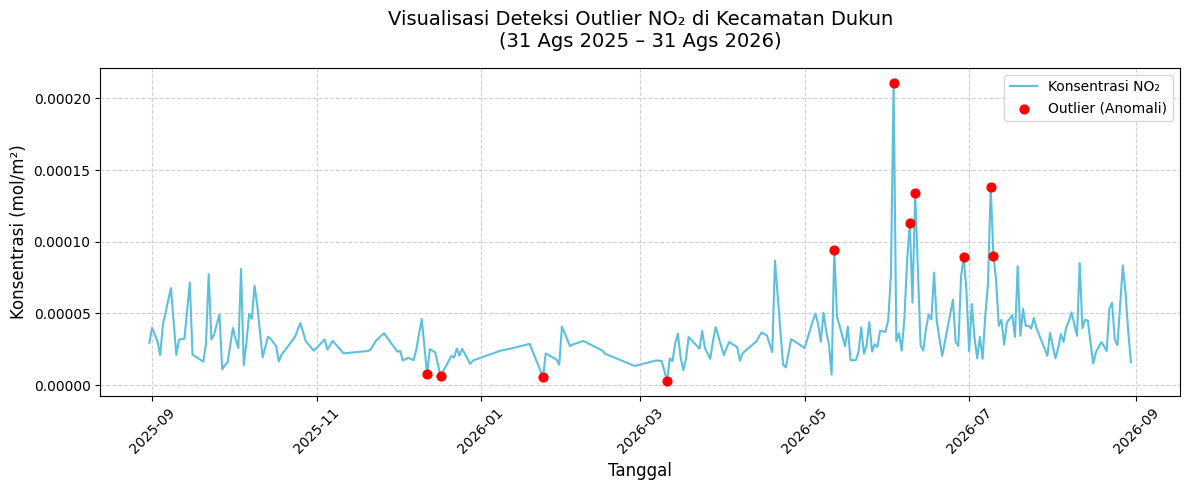

In [3]:
import matplotlib.pyplot as plt

df['date'] = pd.to_datetime(df['date'])

fig, ax = plt.subplots(figsize=(12, 5), dpi=100)

ax.plot(df['date'], df['NO2'], label='Konsentrasi NO₂', color='#5bc0de', linewidth=1.5, zorder=1)

outliers = df[df['outlier'] == -1]

ax.scatter(outliers['date'], outliers['NO2'], color='red', label='Outlier (Anomali)', zorder=2, s=40)

ax.set_title("Visualisasi Deteksi Outlier NO₂ di Kecamatan Dukun\n(31 Ags 2025 – 31 Ags 2026)", fontsize=14, pad=15)
ax.set_xlabel("Tanggal", fontsize=12)
ax.set_ylabel("Konsentrasi (mol/m²)", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Imputasi Missing Values.

Tahap ini akan memasukkan tanggal-tanggal yang bolong ke dalam tabel, lalu mengisi nilai NO2 yang kosong menggunakan Interpolasi Waktu (Time Interpolation).

In [5]:
import pandas as pd
import numpy as np

df.loc[df['outlier'] == -1, 'NO2'] = np.nan

start_date = "2025-08-31"
end_date = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

df = df.set_index('date')

df = df.reindex(full_range)

print(f"Total baris yang kosong (Missing Dates + Outliers yang dihapus): {df['NO2'].isna().sum()} baris")

df['NO2_imputed'] = df['NO2'].interpolate(method='time')

df = df.reset_index().rename(columns={'index': 'date'})

nama_file_bersih = "NO2_Dukun_Cleaned.csv"
df.to_csv(nama_file_bersih, index=False)

print(f"Sisa data kosong setelah imputasi: {df['NO2_imputed'].isna().sum()} baris")
print(f"SUKSES! Data bersih dengan total {len(df)} hari disimpan ke: {nama_file_bersih}")

Total baris yang kosong (Missing Dates + Outliers yang dihapus): 159 baris
Sisa data kosong setelah imputasi: 0 baris
SUKSES! Data bersih dengan total 366 hari disimpan ke: NO2_Dukun_Cleaned.csv


### Visualisasi Hasil Imputasi

Setelah berhasil diisi, kita perlu membuktikan apakah hasil interpolasinya terlihat natural (tidak merusak bentuk grafik).

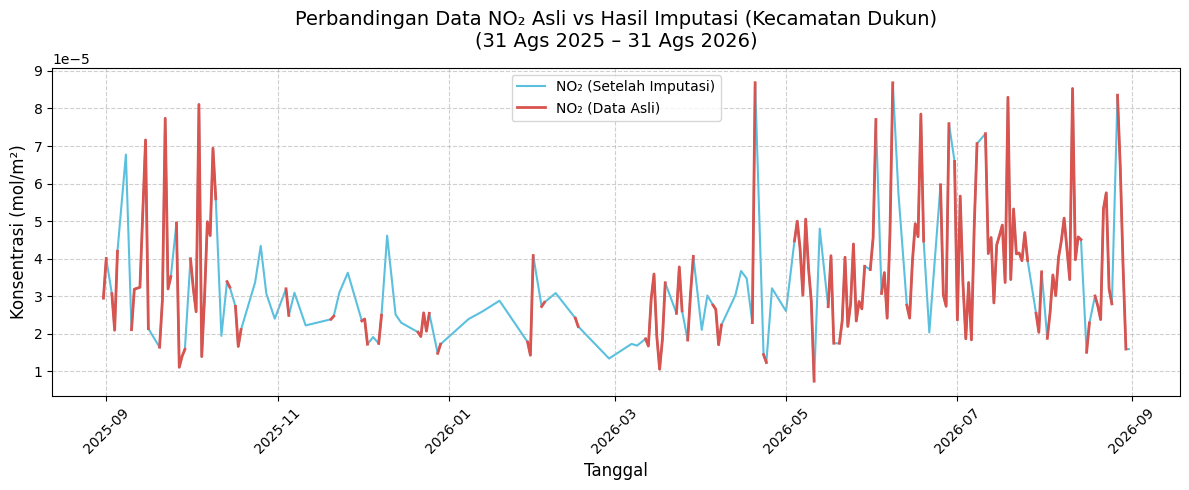

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5), dpi=100)

ax.plot(df['date'], df['NO2_imputed'], linewidth=1.5, label="NO₂ (Setelah Imputasi)", color="#5bc0de", zorder=1)

ax.plot(df['date'], df['NO2'], linewidth=2, label="NO₂ (Data Asli)", color="#d9534f", zorder=2)

ax.set_title("Perbandingan Data NO₂ Asli vs Hasil Imputasi (Kecamatan Dukun)\n(31 Ags 2025 – 31 Ags 2026)", fontsize=14, pad=15)
ax.set_xlabel("Tanggal", fontsize=12)
ax.set_ylabel("Konsentrasi (mol/m²)", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()